# Advanced Behavioral Biometric Feature Analysis (V2) - Parametric Fitting

This notebook enhances the feature extraction process by fitting Keystroke and Mouse Trajectory (KMT) latency data to parametric distributions (**Gamma** and **Log-Normal**). 

### Why Parametric Fitting?
Human timing behavior (keystrokes, latencies) is rarely perfectly normal. It typically exhibits a right-skewed distribution. By fitting these to specific distributions, we can extract:
- **Shape (a/k)**: Captures the 'peakedness' and skewness of the user's behavior.
- **Location (loc)**: Represents the minimum offset (baseline reaction time).
- **Scale (scale)**: Captures the spread or variance of the timings.

These parameters are more stable and harder to spoof than simple means or standard deviations.

In [2]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gamma, lognorm

import warnings
warnings.filterwarnings('ignore')

# Configuration
RAW_DATA_PATH = r'../data_raw/feature_kmt_dataset_Edge_Hill_University_22/feature_kmt_json'
USERS_TO_LOAD = 5  # Demonstrating with first 5 users

## 1. Data Processing Functions

We maintain privacy by extracting only timing latencies and dropping actual key strings.

In [3]:
def get_timings(events):
    """
    Extracts Dwell Times and Digraph Latencies with IQR Outlier Removal.
    """
    last_press = {}
    raw_dwells = []
    raw_digraphs = []
    last_press_time = None

    for event in events:
        key = event.get('Key')
        event_type = event.get('Event')
        try:
            epoch = float(event.get('Epoch'))
        except (ValueError, TypeError):
            continue
            
        if event_type == 'pressed':
            last_press[key] = epoch
            if last_press_time is not None:
                latency = epoch - last_press_time
                if 0 < latency < 5: # Basic range filter
                    raw_digraphs.append(latency)
            last_press_time = epoch
        elif event_type == 'released':
            if key in last_press:
                dwell = epoch - last_press[key]
                if 0 < dwell < 2: # Basic range filter
                    raw_dwells.append(dwell)
                del last_press[key]
    
    def remove_iqr_outliers(data):
        if len(data) < 10: return np.array(data)
        q1, q3 = np.percentile(data, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        # In biometrics, we focus on the upper bound (slow distractions)
        return np.array([x for x in data if max(0.01, lower_bound) <= x <= upper_bound])

    return remove_iqr_outliers(raw_dwells), remove_iqr_outliers(raw_digraphs)

def fit_best_distribution(data):
    """
    Fits Gamma and Log-Normal distributions and returns parameters for both.
    Also returns a flag indicating which one has a better log-likelihood.
    """
    if len(data) < 5:
        return [np.nan] * 7

    # Gamma Fit
    g_shape, g_loc, g_scale = gamma.fit(data, floc=0)
    g_loglik = np.sum(gamma.logpdf(data, g_shape, loc=g_loc, scale=g_scale))

    # Log-Normal Fit
    l_s, l_loc, l_scale = lognorm.fit(data, floc=0)
    l_loglik = np.sum(lognorm.logpdf(data, l_s, loc=l_loc, scale=l_scale))

    better_fit = 'Gamma' if g_loglik > l_loglik else 'Log-Normal'
    
    return [g_shape, g_loc, g_scale, l_s, l_loc, l_scale, better_fit]

## 2. Feature Extraction Pipeline

We process each trial (session) and calculate parametric features for both Dwell Times and Digraph Latencies. We also store the raw timings for visualization.

In [4]:
all_features = []
raw_timings_store = {} # Stores raw data for KDE plotting
file_list = sorted([f for f in os.listdir(RAW_DATA_PATH) if f.endswith('.json')])[:USERS_TO_LOAD]

for file_name in file_list:
    file_path = os.path.join(RAW_DATA_PATH, file_name)
    with open(file_path, 'r') as f:
        data = json.load(f)
        user_id = file_name.split('_')[-1].replace('.json', '')
        raw_timings_store[user_id] = {'true': {}, 'false': {}}
        
        # Process True and False data
        for category in ['true_data', 'false_data']:
            cat_key = 'true' if category == 'true_data' else 'false'
            label = 1 if category == 'true_data' else 0
            for trial_id, trial_data in data.get(category, {}).items():
                events = trial_data.get('key_events', [])
                dwells, digraphs = get_timings(events)
                
                # Store raw for plot
                raw_timings_store[user_id][cat_key][trial_id] = {'dwells': dwells, 'digraphs': digraphs}
                
                # Fit Dwell Times
                dwell_params = fit_best_distribution(dwells)
                # Fit Digraph Latencies
                digraph_params = fit_best_distribution(digraphs)
                
                feature_row = {
                    'user_id': user_id,
                    'trial_id': trial_id,
                    'label': label,
                    # Dwell Parametric Features
                    'dwell_gamma_shape': dwell_params[0],
                    'dwell_gamma_loc': dwell_params[1],
                    'dwell_gamma_scale': dwell_params[2],
                    'dwell_lognorm_s': dwell_params[3],
                    'dwell_lognorm_loc': dwell_params[4],
                    'dwell_lognorm_scale': dwell_params[5],
                    'dwell_best_fit': dwell_params[6],
                    # Digraph Parametric Features
                    'digraph_gamma_shape': digraph_params[0],
                    'digraph_gamma_loc': digraph_params[1],
                    'digraph_gamma_scale': digraph_params[2],
                    'digraph_lognorm_s': digraph_params[3],
                    'digraph_lognorm_loc': digraph_params[4],
                    'digraph_lognorm_scale': digraph_params[5],
                    'digraph_best_fit': digraph_params[6]
                }
                all_features.append(feature_row)

df_features = pd.DataFrame(all_features)
print(f"Extracted parametric features for {len(df_features)} trials.")
display(df_features.head())

Extracted parametric features for 100 trials.


,user_id,trial_id,label,dwell_gamma_shape,dwell_gamma_loc,dwell_gamma_scale,dwell_lognorm_s,dwell_lognorm_loc,dwell_lognorm_scale,dwell_best_fit,digraph_gamma_shape,digraph_gamma_loc,digraph_gamma_scale,digraph_lognorm_s,digraph_lognorm_loc,digraph_lognorm_scale,digraph_best_fit
0,0001,test_1,1,27.332493,0,0.003162,0.194295,0,0.084838,Gamma,2.471326,0,0.059946,0.699024,0,0.119396,Gamma
1,0001,test_2,1,36.094959,0,0.002367,0.169500,0,0.084252,Gamma,5.321330,0,0.022182,0.454099,0,0.107135,Gamma
2,0001,test_3,1,24.226644,0,0.003605,0.209384,0,0.085550,Gamma,4.392992,0,0.028205,0.494156,0,0.110100,Log-Normal
3,0001,test_4,1,27.260723,0,0.003219,0.197891,0,0.086148,Gamma,4.300729,0,0.029913,0.491927,0,0.114015,Log-Normal
4,0001,test_5,1,21.852163,0,0.003766,0.217211,0,0.080422,Gamma,3.528621,0,0.033731,0.557920,0,0.102616,Log-Normal


## 3. Visualization: Individual Trial Fits

We visualize the raw data distribution (Histogram + KDE) against the theoretical PDF curves for a single trial.

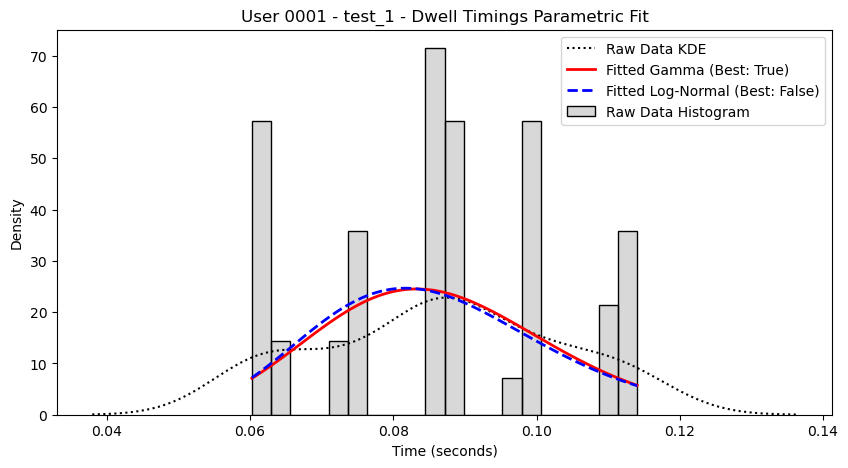

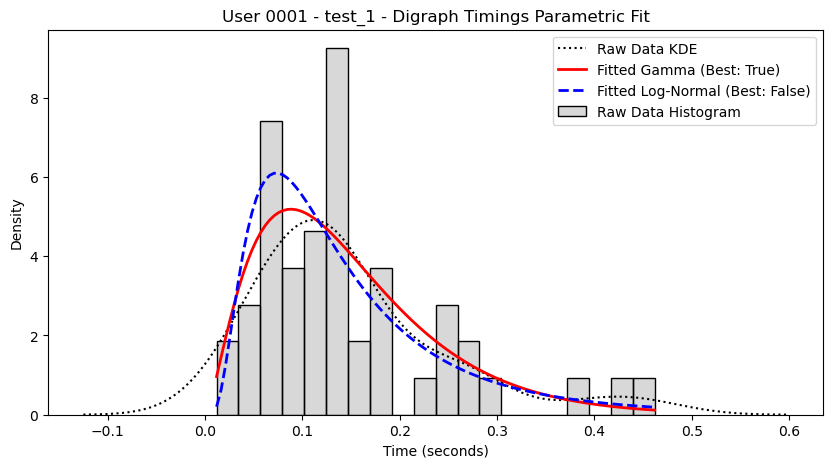

In [5]:
def plot_fitted_distribution(user_id, trial_id, feature_type='dwell'):
    # Retrieve raw data
    trial_data = raw_timings_store.get(user_id, {}).get('true', {}).get(trial_id)
    if not trial_data:
        trial_data = raw_timings_store.get(user_id, {}).get('false', {}).get(trial_id)
    
    if not trial_data: 
        print(f"Trial {trial_id} not found for user {user_id}")
        return
        
    plot_data = trial_data['dwells'] if feature_type == 'dwell' else trial_data['digraphs']
    if len(plot_data) < 5: 
        print("Not enough data to plot")
        return
    
    # Get parameters from our dataframe
    row = df_features[(df_features['user_id'] == user_id) & (df_features['trial_id'] == trial_id)].iloc[0]
    
    plt.figure(figsize=(10, 5))
    
    # 1. Raw Data: Histogram + KDE
    sns.histplot(plot_data, bins=20, stat='density', alpha=0.3, color='gray', label='Raw Data Histogram')
    sns.kdeplot(plot_data, color='black', lw=1.5, label='Raw Data KDE', linestyle=':')
    
    # 2. Theoretical PDF Curves
    x = np.linspace(min(plot_data), max(plot_data), 100)
    
    # Plot Gamma
    y_gamma = stats.gamma.pdf(x, row[f'{feature_type}_gamma_shape'], loc=row[f'{feature_type}_gamma_loc'], scale=row[f'{feature_type}_gamma_scale'])
    plt.plot(x, y_gamma, 'r-', lw=2, label=f'Fitted Gamma (Best: {row[feature_type + "_best_fit"] == "Gamma"})')
    
    # Plot Log-Normal
    y_lognorm = stats.lognorm.pdf(x, row[f'{feature_type}_lognorm_s'], loc=row[f'{feature_type}_lognorm_loc'], scale=row[f'{feature_type}_lognorm_scale'])
    plt.plot(x, y_lognorm, 'b--', lw=2, label=f'Fitted Log-Normal (Best: {row[feature_type + "_best_fit"] == "Log-Normal"})')
    
    plt.title(f'User {user_id} - {trial_id} - {feature_type.capitalize()} Timings Parametric Fit')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

# Visualize first user, first trial
plot_fitted_distribution('0001', 'test_1', feature_type='dwell')
plot_fitted_distribution('0001', 'test_1', feature_type='digraph')

## 4. Multi-User Profile Comparison (Advanced Visualization)

This visualization overlays the theoretical **Gamma PDF** curves of different users. Crucially, it also plots the **Raw Data KDEs** for every trial in a lighter shade of the same color. This demonstrates the consistency of the user's behavior and the robustness of the parametric model.

Comparing Dwell Time Profiles...


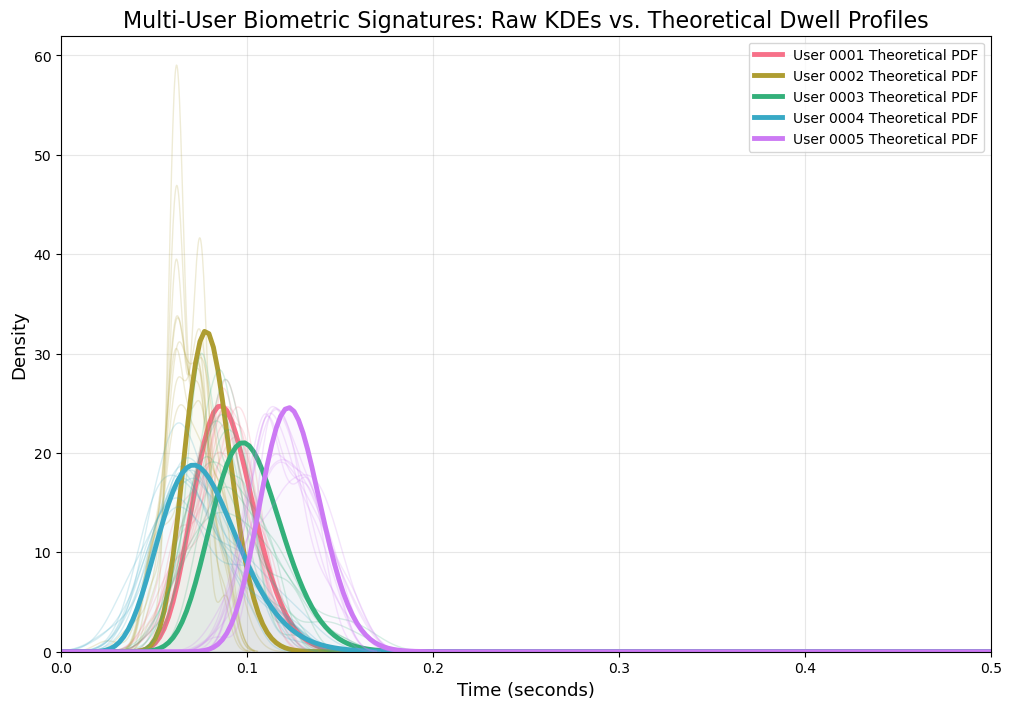


Comparing Digraph Latency Profiles...


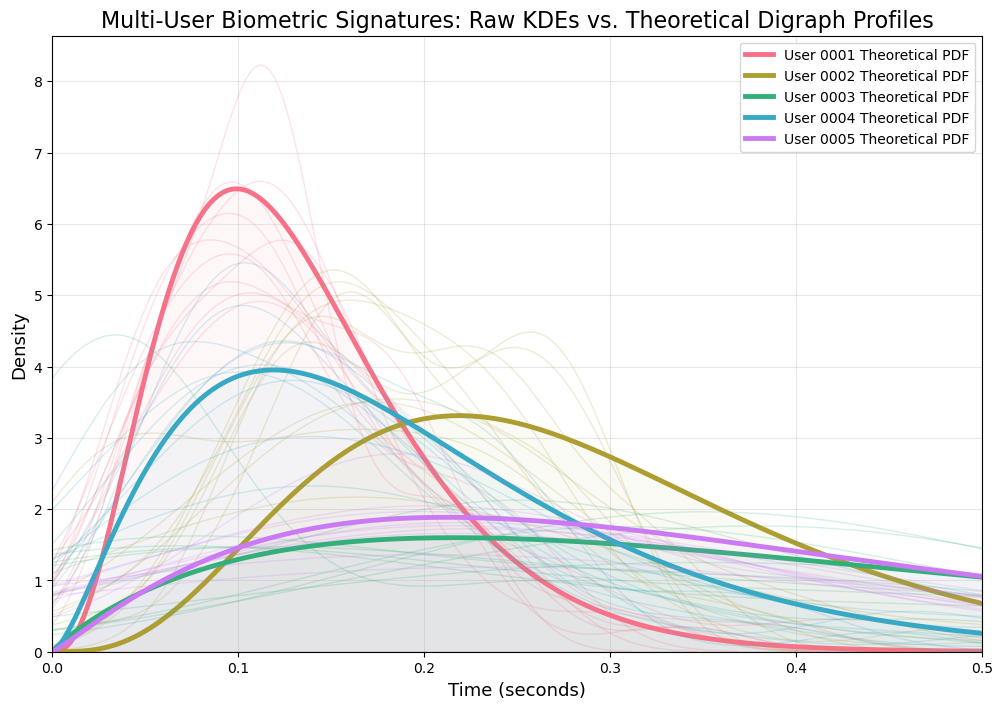

In [6]:
def plot_multi_user_comparison(user_list, feature_type='dwell'):
    plt.figure(figsize=(12, 8))
    colors = sns.color_palette('husl', len(user_list))
    
    x = np.linspace(0, 0.6, 250) 

    for idx, user_id in enumerate(user_list):
        color = colors[idx]
        
        # 1. Plot individual trial raw distributions (faint lines)
        trials = raw_timings_store.get(user_id, {}).get('true', {})
        for t_id, t_data in trials.items():
            data = t_data['dwells'] if feature_type == 'dwell' else t_data['digraphs']
            if len(data) > 1:
                sns.kdeplot(data, color=color, alpha=0.2, lw=1)
        
        # 2. Plot Theoretical Average Profile (Bold Line)
        user_rows = df_features[(df_features['user_id'] == user_id) & (df_features['label'] == 1)]
        if user_rows.empty: continue
        
        avg_shape = user_rows[f'{feature_type}_gamma_shape'].mean()
        avg_loc = user_rows[f'{feature_type}_gamma_loc'].mean()
        avg_scale = user_rows[f'{feature_type}_gamma_scale'].mean()

        y_pdf = stats.gamma.pdf(x, avg_shape, loc=avg_loc, scale=avg_scale)
        plt.plot(x, y_pdf, color=color, lw=3.5, label=f'User {user_id} Theoretical PDF')
        
        # Optional: Shading
        plt.fill_between(x, y_pdf, alpha=0.05, color=color)

    plt.title(f'Multi-User Biometric Signatures: Raw KDEs vs. Theoretical {feature_type.capitalize()} Profiles', fontsize=16)
    plt.xlabel('Time (seconds)', fontsize=13)
    plt.ylabel('Density', fontsize=13)
    plt.xlim(0, 0.5)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Compare First 5 Users for both Dwell and Digraph
top_5_users = sorted(df_features['user_id'].unique())[:5]
print("Comparing Dwell Time Profiles...")
plot_multi_user_comparison(top_5_users, feature_type='dwell')

print("\nComparing Digraph Latency Profiles...")
plot_multi_user_comparison(top_5_users, feature_type='digraph')